#HW2 Анисимов Андрей Дмитриевич РИ-421003

##Данные

In [ ]:
!pip install "numpy<2"

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dateutil.relativedelta import relativedelta
from scipy.optimize import minimize

import statsmodels.formula.api as smf
import statsmodels.tsa.api as smt
import statsmodels.api as sm
import scipy.stats as scs

from itertools import product
from tqdm import tqdm_notebook

%matplotlib inline

In [ ]:
from sklearn.metrics import r2_score, median_absolute_error, mean_absolute_error
from sklearn.metrics import median_absolute_error, mean_squared_error, mean_squared_log_error

In [ ]:
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [ ]:
df = pd.read_csv('/content/machine_temperature_system_failure.csv', index_col=['timestamp'], parse_dates=['timestamp'])
df

,value
timestamp,
2013-12-02 21:15:00,73.967322
2013-12-02 21:20:00,74.935882
2013-12-02 21:25:00,76.124162
2013-12-02 21:30:00,78.140707
2013-12-02 21:35:00,79.329836
...,...
2014-02-19 15:05:00,98.185415
2014-02-19 15:10:00,97.804168
2014-02-19 15:15:00,97.135468


###Визуализируйте ряд и на основе его внешнего вида сделайте предположения о его компонентах (тренд, сезонность) и стационарности - 1 балл

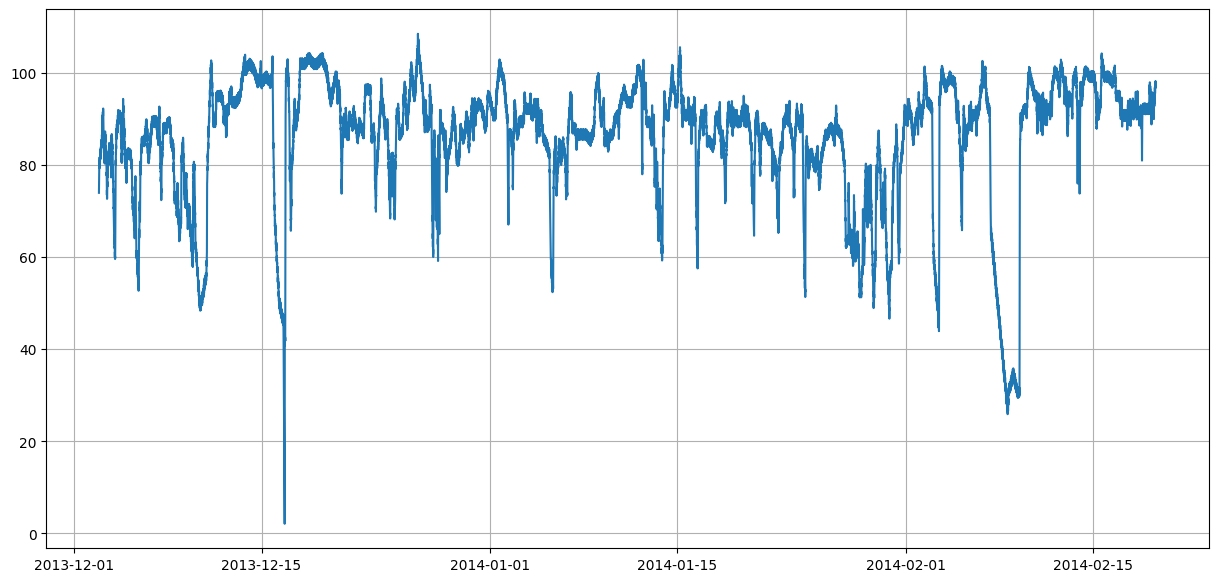

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(df.value)
plt.grid(True)
plt.show()

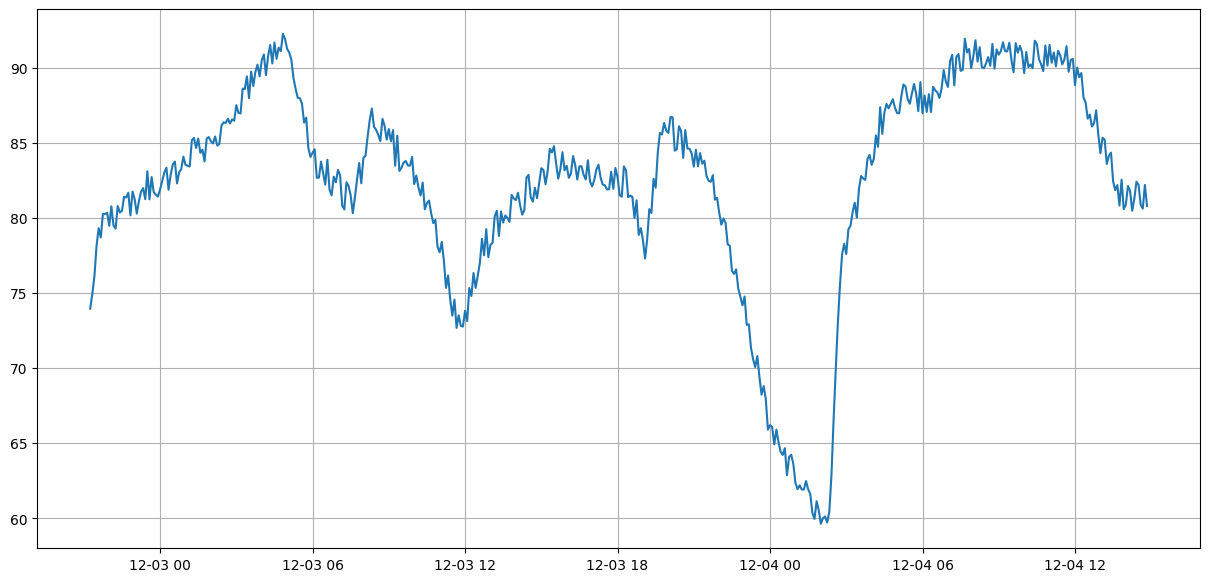

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(df.value.head(500))
plt.grid(True)
plt.show()

Ввиду того, что в ряду не прослеживается тренд и сезонность можно сделать предположение, что он является стационарным

###Сделайте train/test split

In [ ]:
# Разделение на train/test (70%/30%)
split_index = int(len(df) * 0.7)
train = df.iloc[:split_index]
test = df.iloc[split_index:]

###Выбреите релевантную, на ваш взгляд, метрику для последующих замеров качества

Средняя абсолютная ошибка (Mean Absolute Error, MAE): метрика, которая измеряет среднюю абсолютную разницу между фактическими и прогнозными значениями.


#Прогнозирование

##Бейзлайн

###Постройте бейзлайн в виде наивного прогноза или скользящего среднего - 2 балла

In [ ]:
def plotMovingAverage(series, window, plot_intervals=False, scale=1.96, plot_anomalies=False):

    """
        series - dataframe with timeseries
        window - rolling window size
        plot_intervals - show confidence intervals
        plot_anomalies - show anomalies

    """
    rolling_mean = series.rolling(window=window).mean()

    plt.figure(figsize=(15,5))
    plt.title("Moving average\n window size = {}".format(window))
    plt.plot(rolling_mean, "g", label="Rolling mean trend")

    # Plot confidence intervals for smoothed values
    if plot_intervals:
        mae = mean_absolute_error(series[window:], rolling_mean[window:])
        deviation = np.std(series[window:] - rolling_mean[window:])
        lower_bond = rolling_mean - (mae + scale * deviation)
        upper_bond = rolling_mean + (mae + scale * deviation)
        plt.plot(upper_bond, "r--", label="Upper Bond / Lower Bond")
        plt.plot(lower_bond, "r--")

        # Having the intervals, find abnormal values
        if plot_anomalies:
            anomalies = pd.DataFrame(index=series.index, columns=series.columns)
            anomalies[series<lower_bond] = series[series<lower_bond]
            anomalies[series>upper_bond] = series[series>upper_bond]
            plt.plot(anomalies, "ro", markersize=10)

    plt.plot(series[window:], label="Actual values")
    plt.legend(loc="upper left")
    plt.grid(True)



###Визуализируйте результаты работы модели, произведите замеры качества с выбранной метрикой - 1 балл

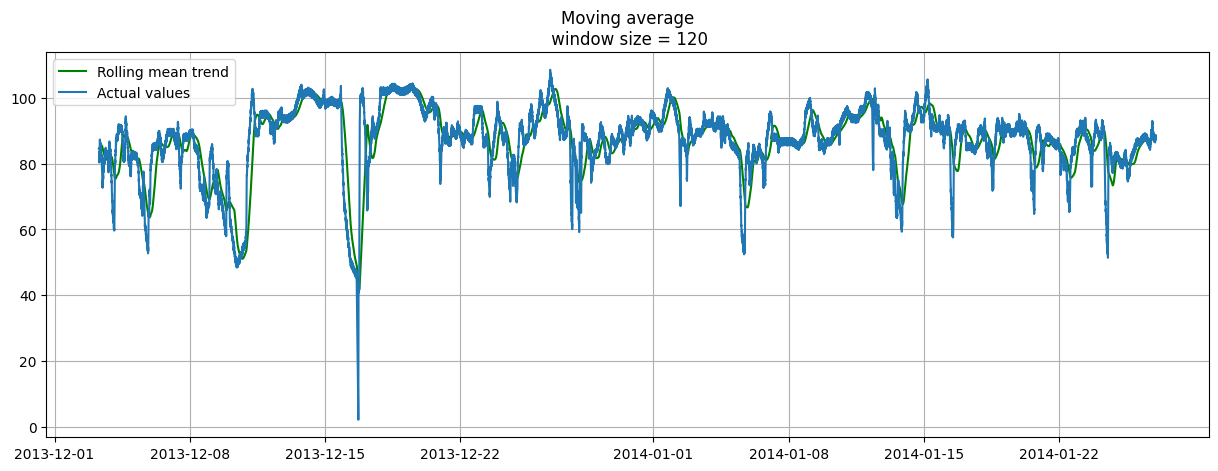

In [ ]:
plotMovingAverage(train, 120)

In [ ]:
def calculate_metrics(y_true, y_pred, model_name="Model"):
    """Вычисление основных метрик качества прогноза"""



##Статстическая модель

In [ ]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df.value)

adf_result_summary = {
    "ADF Statistic": adf_result[0],
    "p-value": adf_result[1],
    "Used lags": adf_result[2],
    "Number of observations": adf_result[3],
    "Critical Values": adf_result[4]
}

for key, value in adf_result_summary.items():
    print(f"{key}: {value}")

ADF Statistic: -7.3690895644913414
p-value: 9.071345315518266e-11
Used lags: 20
Number of observations: 22674
Critical Values: {'1%': -3.4306384378792365, '5%': -2.861667480233377, '10%': -2.566837854101014}


Результаты теста - p-value << 0.05 значит гипотеза о нестационарности подтверждается.

In [ ]:
def tsplot(y, lags=None, figsize=(12, 7), style='bmh'):
    """
        Plot time series, its ACF and PACF, calculate Dickey–Fuller test

        y - timeseries
        lags - how many lags to include in ACF, PACF calculation
    """
    if not isinstance(y, pd.Series):
        y = pd.Series(y)

    with plt.style.context(style):
        fig = plt.figure(figsize=figsize)
        layout = (2, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))

        y.plot(ax=ts_ax)
        p_value = sm.tsa.stattools.adfuller(y)[1]
        ts_ax.set_title('Time Series Analysis Plots\n Dickey-Fuller: p={0:.5f}'.format(p_value))
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax)
        plt.tight_layout()

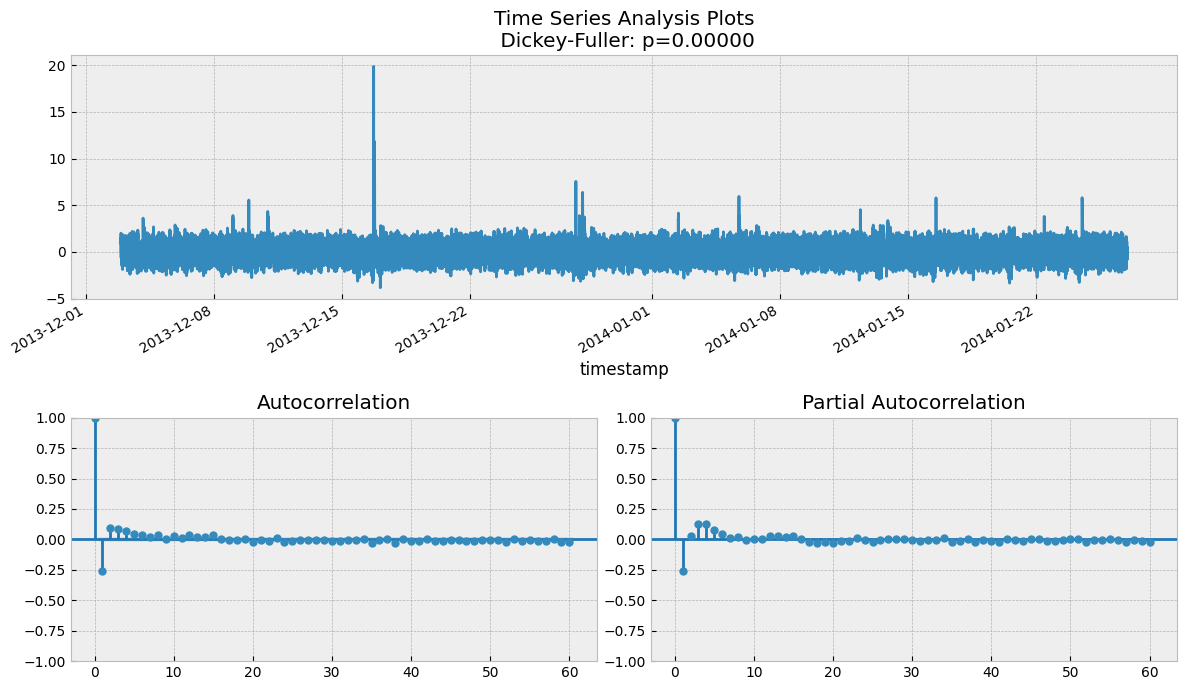

In [ ]:
train_diff = train.diff().dropna()
tsplot(train_diff.value, lags=60)

###Обучите модель ARIMA или SARIMA для прогнозирования значений ряда, подобрав оптимальные параметры

In [ ]:
!pip install numpy==1.26.4 pmdarima==2.0.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 18.5 MB/s eta 0:00:00


In [ ]:
from pmdarima import auto_arima

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                22695
Model:               SARIMAX(1, 1, 2)   Log Likelihood              -32643.603
Date:                Thu, 30 Oct 2025   AIC                          65295.207
Time:                        16:16:22   BIC                          65327.326
Sample:                             0   HQIC                         65305.651
                              - 22695                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7641      0.011     70.228      0.000       0.743       0.785
ma.L1         -1.0368      0.010   -105.717      0.000      -1.056      -1.018
ma.L2          0.3379      0.003     96.673      0.0

In [ ]:
model = auto_arima(df.value)
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                22695
Model:               SARIMAX(1, 1, 2)   Log Likelihood              -32643.603
Date:                Thu, 30 Oct 2025   AIC                          65295.207
Time:                        16:19:51   BIC                          65327.326
Sample:                             0   HQIC                         65305.651
                              - 22695                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7641      0.011     70.228      0.000       0.743       0.785
ma.L1         -1.0368      0.010   -105.717      0.000      -1.056      -1.018
ma.L2          0.3379      0.003     96.673      0.0

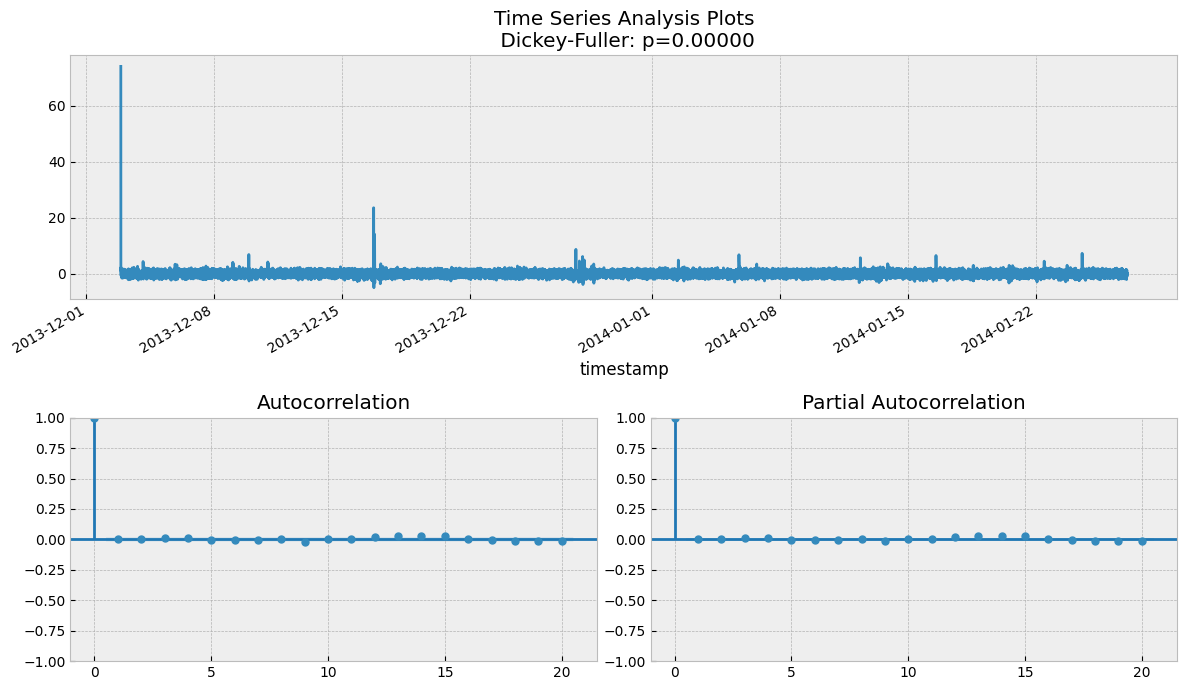

In [ ]:
tsplot(model.resid(), 20)

##Классическая модель


###Используйте Feature-Engineering для создания признаков (лаги, скользящие статистики, признаки даты/времени, etc) - 3 балла

####Лаги

In [ ]:
data = pd.DataFrame(df.value.copy())
data.columns = ["y"]

In [ ]:
for i in range(6, 25):
    data["lag_{}".format(i)] = data.y.shift(i)

In [ ]:
data.tail(7)

,y,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24
timestamp,,,,,,,,,,,,,,,,,,,,
2014-02-19 14:55:00,98.162952,97.760870,95.961107,96.103572,95.556043,97.184352,95.108901,94.900900,96.820556,95.377308,94.657280,95.553183,94.806127,94.534074,94.617205,94.342091,93.650855,94.124466,93.405691,95.015458
2014-02-19 15:00:00,97.360905,97.175704,97.760870,95.961107,96.103572,95.556043,97.184352,95.108901,94.900900,96.820556,95.377308,94.657280,95.553183,94.806127,94.534074,94.617205,94.342091,93.650855,94.124466,93.405691
2014-02-19 15:05:00,98.185415,96.768563,97.175704,97.760870,95.961107,96.103572,95.556043,97.184352,95.108901,94.900900,96.820556,95.377308,94.657280,95.553183,94.806127,94.534074,94.617205,94.342091,93.650855,94.124466
2014-02-19 15:10:00,97.804168,96.739868,96.768563,97.175704,97.760870,95.961107,96.103572,95.556043,97.184352,95.108901,94.900900,96.820556,95.377308,94.657280,95.553183,94.806127,94.534074,94.617205,94.342091,93.650855
2014-02-19 15:15:00,97.135468,97.284578,96.739868,96.768563,97.175704,97.760870,95.961107,96.103572,95.556043,97.184352,95.108901,94.900900,96.820556,95.377308,94.657280,95.553183,94.806127,94.534074,94.617205,94.342091
2014-02-19 15:20:00,98.056852,97.549774,97.284578,96.739868,96.768563,97.175704,97.760870,95.961107,96.103572,95.556043,97.184352,95.108901,94.900900,96.820556,95.377308,94.657280,95.553183,94.806127,94.534074,94.617205
2014-02-19 15:25:00,96.903861,98.162952,97.549774,97.284578,96.739868,96.768563,97.175704,97.760870,95.961107,96.103572,95.556043,97.184352,95.108901,94.900900,96.820556,95.377308,94.657280,95.553183,94.806127,94.534074


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
def timeseries_train_test_split(X, y, test_size):
    """
        Perform train-test split with respect to time series structure
    """

    # get the index after which test set starts
    test_index = int(len(X)*(1-test_size))

    X_train = X.iloc[:test_index]
    y_train = y.iloc[:test_index]
    X_test = X.iloc[test_index:]
    y_test = y.iloc[test_index:]

    return X_train, X_test, y_train, y_test

In [ ]:
y = data.dropna().y
X = data.dropna().drop(['y'], axis=1)

# reserve 30% of data for testing
X_train, X_test, y_train, y_test = timeseries_train_test_split(X, y, test_size=0.3)

In [ ]:
# machine learning in two lines
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
def plotModelResults(model, X_train=X_train, X_test=X_test, plot_intervals=False, plot_anomalies=False):
    """
        Plots modelled vs fact values, prediction intervals and anomalies

    """

    prediction = model.predict(X_test)

    plt.figure(figsize=(15, 7))
    plt.plot(prediction, "g", label="prediction", linewidth=2.0)
    plt.plot(y_test.values, label="actual", linewidth=2.0)

    if plot_intervals:
        cv = cross_val_score(model, X_train, y_train,
                                    cv=tscv,
                                    scoring="neg_mean_absolute_error")
        mae = cv.mean() * (-1)
        deviation = cv.std()

        scale = 1.96
        lower = prediction - (mae + scale * deviation)
        upper = prediction + (mae + scale * deviation)

        plt.plot(lower, "r--", label="upper bond / lower bond", alpha=0.5)
        plt.plot(upper, "r--", alpha=0.5)

        if plot_anomalies:
            anomalies = np.array([np.NaN]*len(y_test))
            anomalies[y_test<lower] = y_test[y_test<lower]
            anomalies[y_test>upper] = y_test[y_test>upper]
            plt.plot(anomalies, "o", markersize=10, label = "Anomalies")

    error = mean_absolute_percentage_error(prediction, y_test)
    plt.title("Mean absolute percentage error {0:.2f}%".format(error))
    plt.legend(loc="best")
    plt.tight_layout()
    plt.grid(True);

def plotCoefficients(model):
    """
        Plots sorted coefficient values of the model
    """

    coefs = pd.DataFrame(model.coef_, X_train.columns)
    coefs.columns = ["coef"]
    coefs["abs"] = coefs.coef.apply(np.abs)
    coefs = coefs.sort_values(by="abs", ascending=False).drop(["abs"], axis=1)

    plt.figure(figsize=(15, 7))
    coefs.coef.plot(kind='bar')
    plt.grid(True, axis='y')
    plt.hlines(y=0, xmin=0, xmax=len(coefs), linestyles='dashed');

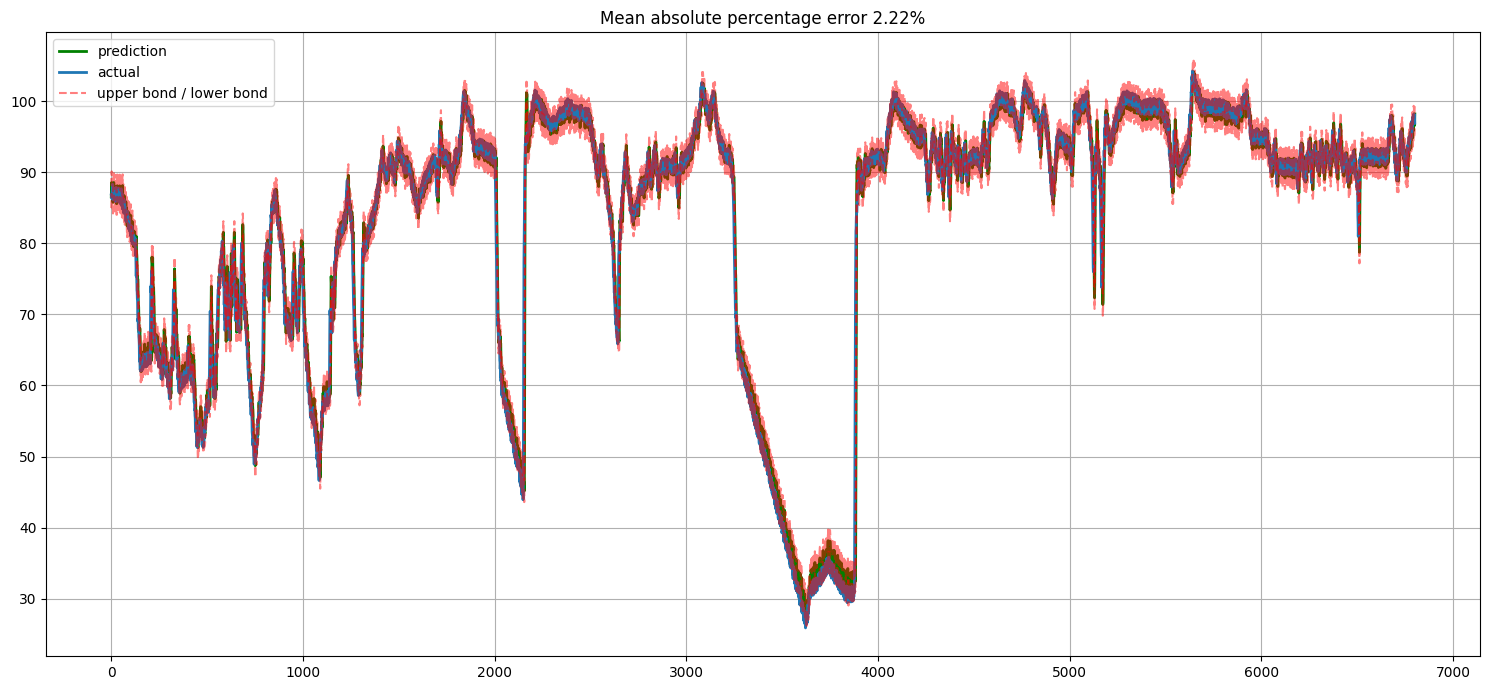

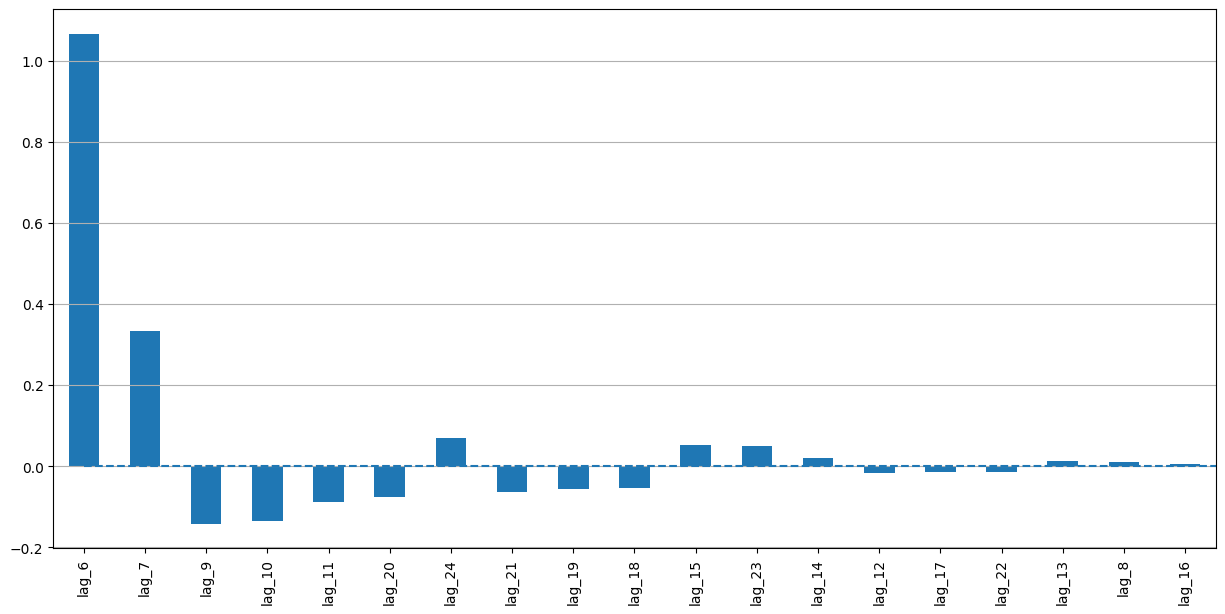

In [ ]:
plotModelResults(lr, plot_intervals=True)
plotCoefficients(lr)

####Признаки из даты и времени

In [ ]:
data.index = pd.to_datetime(data.index)
data["hour"] = data.index.hour
data["weekday"] = data.index.weekday
data['is_weekend'] = data.weekday.isin([5, 6]) * 1
data.tail()

,y,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,...,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,hour,weekday,is_weekend
timestamp,,,,,,,,,,,,,,,,,,,,,
2014-02-19 15:05:00,98.185415,96.768563,97.175704,97.760870,95.961107,96.103572,95.556043,97.184352,95.108901,94.900900,...,95.553183,94.806127,94.534074,94.617205,94.342091,93.650855,94.124466,15,2,0
2014-02-19 15:10:00,97.804168,96.739868,96.768563,97.175704,97.760870,95.961107,96.103572,95.556043,97.184352,95.108901,...,94.657280,95.553183,94.806127,94.534074,94.617205,94.342091,93.650855,15,2,0
2014-02-19 15:15:00,97.135468,97.284578,96.739868,96.768563,97.175704,97.760870,95.961107,96.103572,95.556043,97.184352,...,95.377308,94.657280,95.553183,94.806127,94.534074,94.617205,94.342091,15,2,0
2014-02-19 15:20:00,98.056852,97.549774,97.284578,96.739868,96.768563,97.175704,97.760870,95.961107,96.103572,95.556043,...,96.820556,95.377308,94.657280,95.553183,94.806127,94.534074,94.617205,15,2,0
2014-02-19 15:25:00,96.903861,98.162952,97.549774,97.284578,96.739868,96.768563,97.175704,97.760870,95.961107,96.103572,...,94.900900,96.820556,95.377308,94.657280,95.553183,94.806127,94.534074,15,2,0


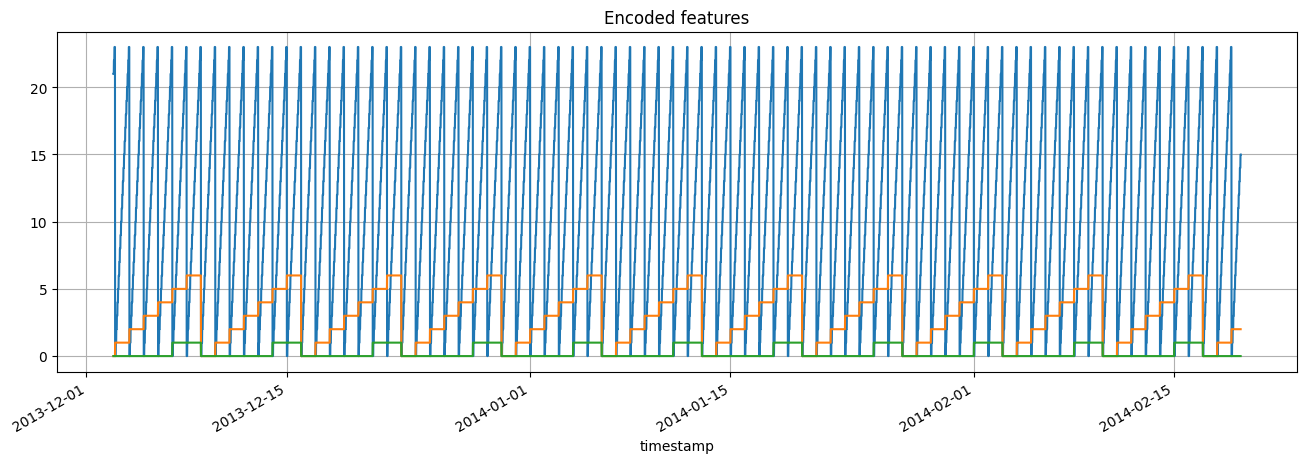

In [ ]:
plt.figure(figsize=(16, 5))
plt.title("Encoded features")
data.hour.plot()
data.weekday.plot()
data.is_weekend.plot()
plt.grid(True);

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

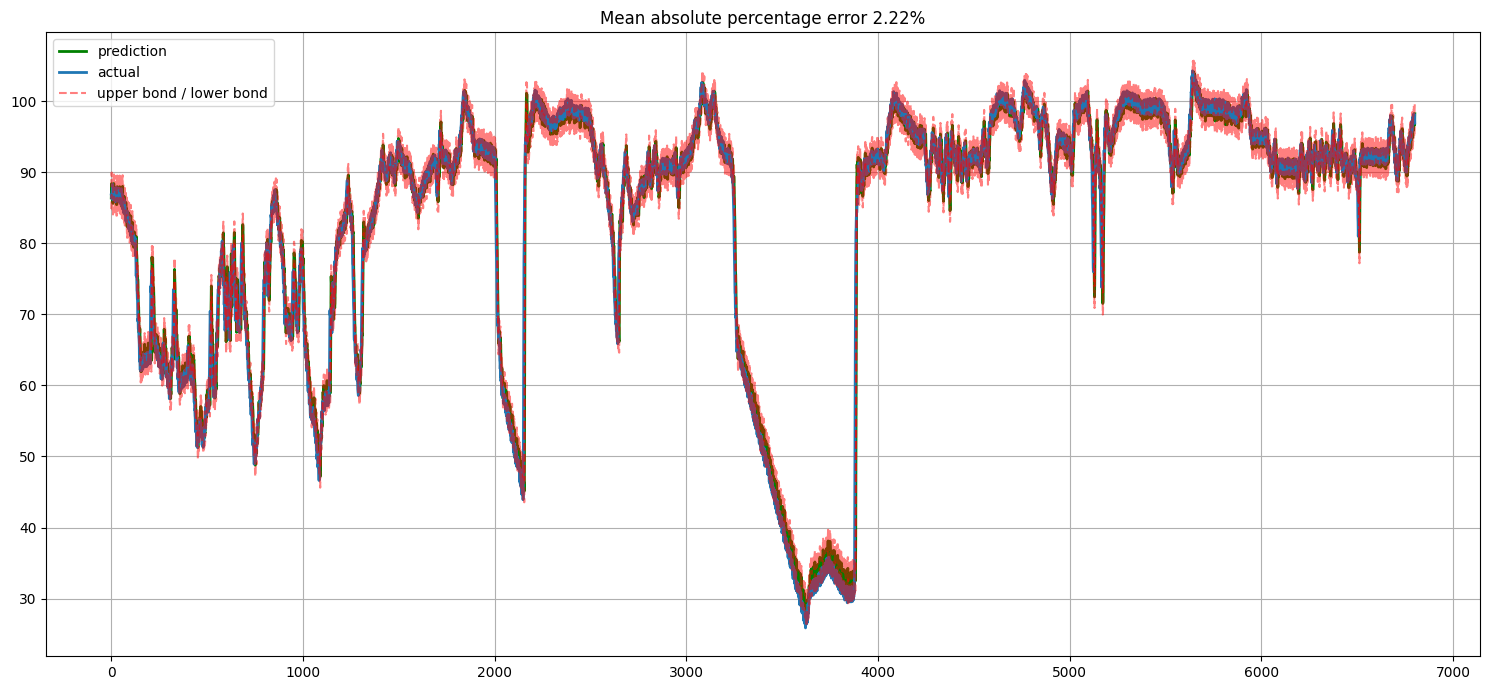

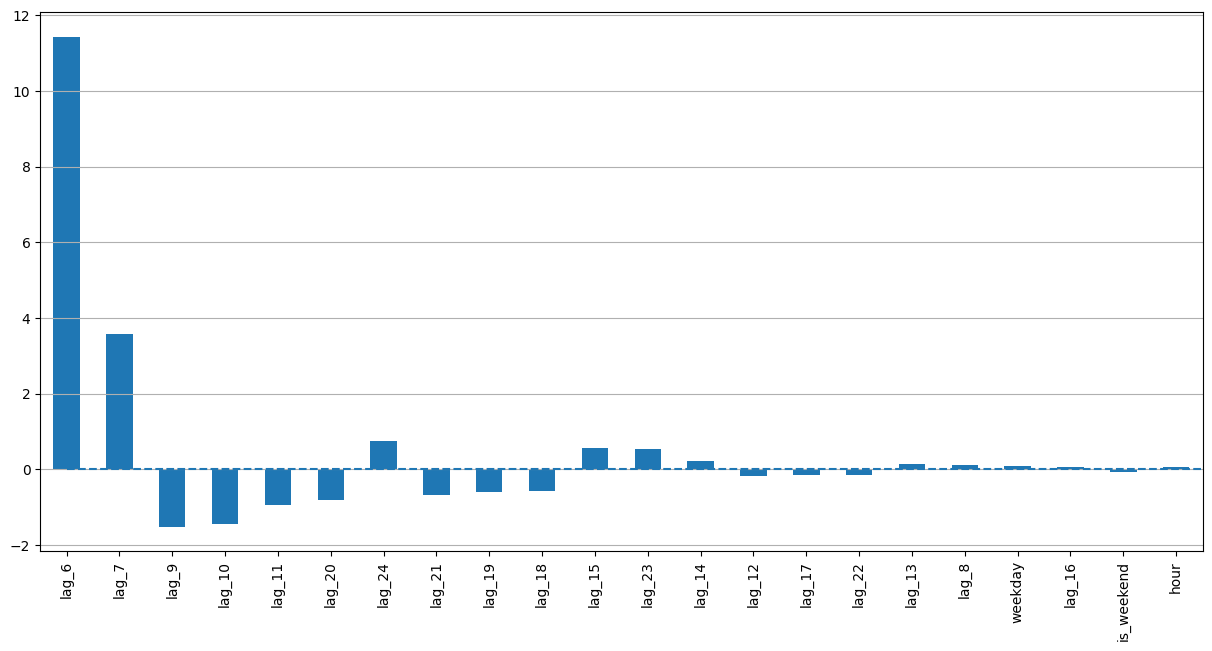

In [ ]:
y = data.dropna().y
X = data.dropna().drop(['y'], axis=1)

X_train, X_test, y_train, y_test = timeseries_train_test_split(X, y, test_size=0.3)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

plotModelResults(lr, X_train=X_train_scaled, X_test=X_test_scaled, plot_intervals=True)
plotCoefficients(lr)

###На полученном наборе данных обучите случайный лес или градиентный бустинг - 2 балла

###Бустинг

In [ ]:
!pip install catboost

In [ ]:
from catboost import CatBoostRegressor

In [ ]:
catboost_model = CatBoostRegressor(random_seed=42, logging_level='Silent')
catboost_model.fit(X_train, y_train, plot=False)

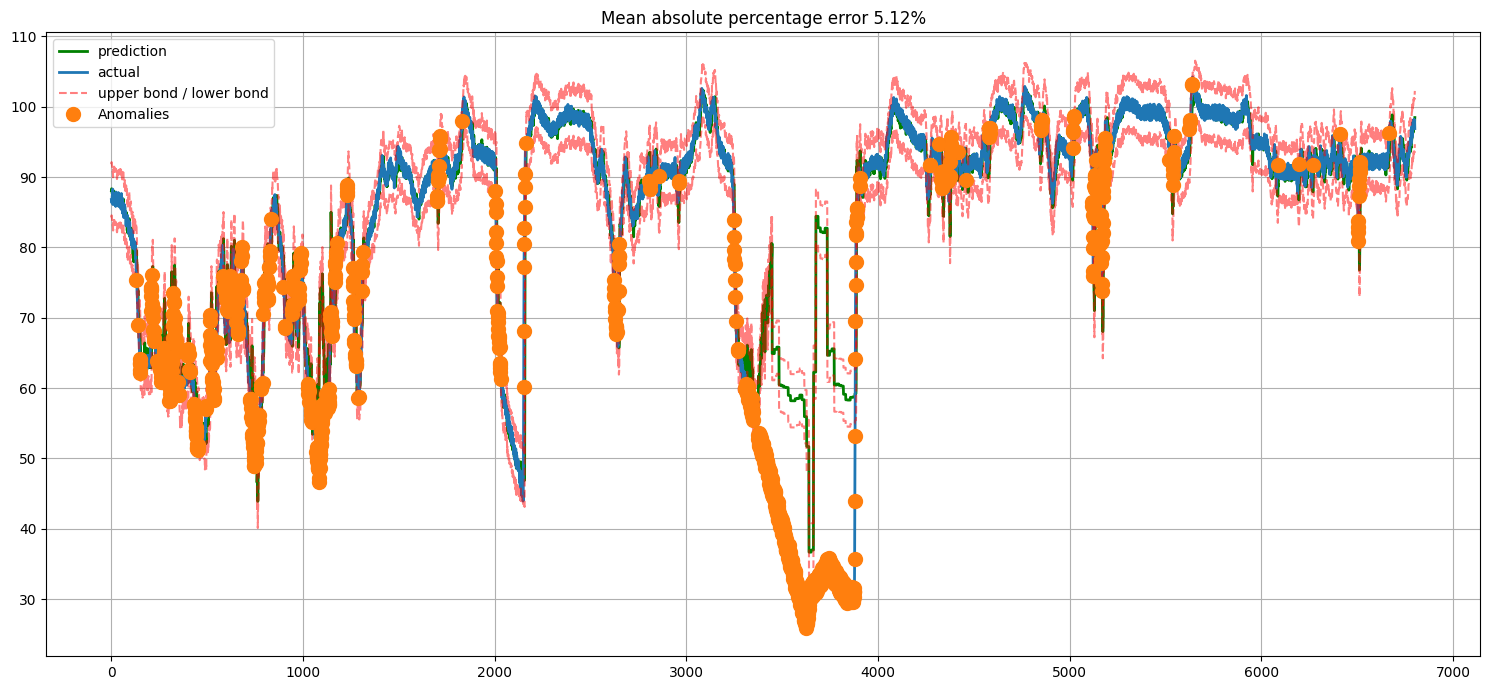

In [ ]:
plotModelResults(catboost_model, X_train=X_train, X_test=X_test, plot_intervals=True, plot_anomalies=True)

##Нейросетевая модель

###Обучить на выбранном временном ряду модель RNNModel из библиотеки ETNA - 1 балл

In [ ]:
!pip install etna[torch]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.2/565.2 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.5/828.5 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 44.7 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing i

In [ ]:
import pandas as pd
from etna.datasets import TSDataset
from etna.transforms import StandardScalerTransform
from etna.pipeline import Pipeline
import matplotlib.pyplot as plt
from datetime import timedelta
from etna.datasets import TSDataset
from etna.models.nn import RNNModel,DeepARModel
from etna.transforms import DateFlagsTransform, LagTransform, FourierTransform, TimeSeriesImputerTransform, MeanTransform, StandardScalerTransform
from etna.pipeline import Pipeline
from etna.models.nn import RNNModel, DeepARModel
from etna.metrics import MAE, RMSE, MAPE

In [ ]:

df = pd.read_csv('/machine_temperature_system_failure.csv', parse_dates=['timestamp'])
df.head()

,timestamp,value
0,2013-12-02 21:15:00,73.967322
1,2013-12-02 21:20:00,74.935882
2,2013-12-02 21:25:00,76.124162
3,2013-12-02 21:30:00,78.140707
4,2013-12-02 21:35:00,79.329836


In [ ]:
df = df.rename(columns={'value': 'target'})
df['segment'] = 'main'
df.head()


,timestamp,target,segment
0,2013-12-02 21:15:00,73.967322,main
1,2013-12-02 21:20:00,74.935882,main
2,2013-12-02 21:25:00,76.124162,main
3,2013-12-02 21:30:00,78.140707,main
4,2013-12-02 21:35:00,79.329836,main


In [ ]:
# First, ensure no duplicates
df = df.drop_duplicates(subset=['timestamp', 'segment']).reset_index(drop=True)

# Sort by timestamp (good practice)
df = df.sort_values(['segment', 'timestamp'])

# Use appropriate frequency: '5T' for 5-minute intervals
ts = TSDataset(df, freq='5T')
ts.head()

segment,main
feature,target
timestamp,
2013-12-02 21:15:00,73.967322
2013-12-02 21:20:00,74.935882
2013-12-02 21:25:00,76.124162
2013-12-02 21:30:00,78.140707
2013-12-02 21:35:00,79.329836


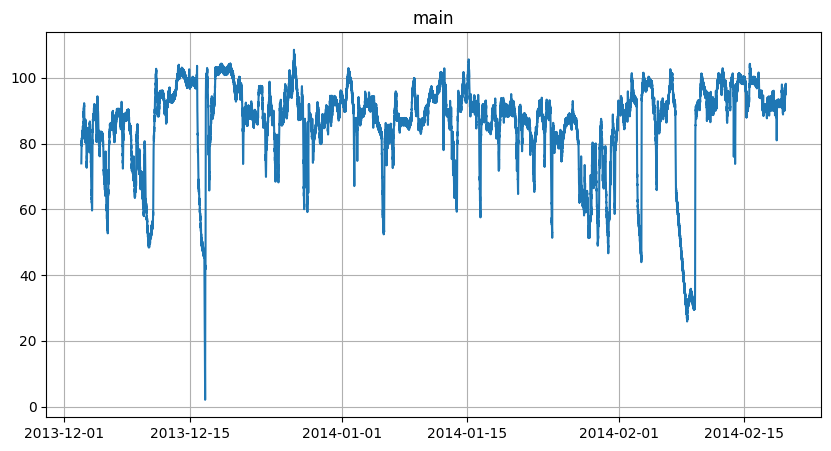

In [ ]:
ts.plot()

In [ ]:
base_transforms = [
    TimeSeriesImputerTransform(in_column="target"),
    FourierTransform(period=288, order=2),
    LagTransform(in_column="target", lags=[1, 12, 288])
]

# === Применяем трансформы ===
ts.fit_transform(base_transforms)

In [ ]:
ts.describe()

,start_timestamp,end_timestamp,length,num_missing,num_segments,num_exogs,num_regressors,num_known_future,freq
segments,,,,,,,,,
main,2013-12-02 21:15:00,2014-02-19 15:25:00,22683,0,1,0,0,0,5min


In [ ]:
data = pd.DataFrame(pd.read_csv('/machine_temperature_system_failure.csv'))
data['timestamp'] = pd.to_datetime(data['timestamp'])
data = data.drop_duplicates(subset=['timestamp'], keep='first')
data = data.set_index('timestamp')
data = data.asfreq('5T', method='pad')
data = data.reset_index()
data.head()

,timestamp,value
0,2013-12-02 21:15:00,73.967322
1,2013-12-02 21:20:00,74.935882
2,2013-12-02 21:25:00,76.124162
3,2013-12-02 21:30:00,78.140707
4,2013-12-02 21:35:00,79.329836


In [ ]:
target_feature = 'value'
df_etna = data[['timestamp', target_feature]].rename(columns={target_feature: "target", "timestamp": "timestamp"})
df_etna["segment"] = "default"

In [ ]:
ts = TSDataset(df_etna, freq="5T")

In [ ]:
base_transforms = [
    TimeSeriesImputerTransform(in_column="target"),
    FourierTransform(period=288, order=2),
    LagTransform(in_column="target", lags=[1, 12, 288])
]

# === Применяем трансформы ===
ts.fit_transform(base_transforms)

In [ ]:
train_ts, test_ts = ts.train_test_split(test_size=4500)

In [ ]:
rnn_model = RNNModel(input_size=8, decoder_length=24, encoder_length=288, trainer_params=dict(max_epochs=10))

In [ ]:
rnn_model.fit(train_ts)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: 
  | Name       | Type    | Params | Mode 
-----------------------------------------------
0 | loss       | MSELoss | 0      | train
1 | rnn        | LSTM    | 3.8 K 

Training: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


RNNModel(input_size = 8, decoder_length = 24, encoder_length = 288, num_layers = 2, hidden_size = 16, embedding_sizes = None, lr = 0.001, loss = None, train_batch_size = 16, test_batch_size = 16, optimizer_params = None, trainer_params = {'max_epochs': 10, 'logger': []}, train_dataloader_params = {}, test_dataloader_params = {}, val_dataloader_params = {}, split_params = {}, )

In [ ]:
forecast_rnn = rnn_model.forecast(test_ts, 4212)
y_true = test_ts.to_pandas()['default']["target"][:4212]
y_pred_rnn = forecast_rnn.to_pandas()['default']["target"]
mae_rnn = mean_absolute_error(y_true, y_pred_rnn)

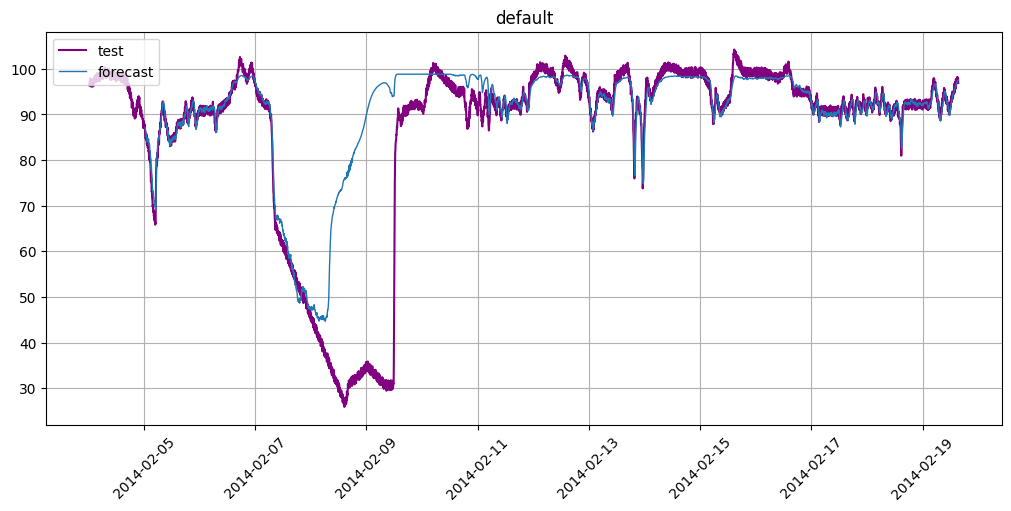

In [ ]:
from etna.analysis import plot_forecast

plot_forecast(
    forecast_rnn,
    test_ts,
    segments=["default"]
)

####DeepAR

In [ ]:
deepar_model = DeepARModel(input_size=8, decoder_length=3, encoder_length=24, trainer_params=dict(max_epochs=15))

In [ ]:
deepar_model.fit(train_ts)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: 
  | Name       | Type         | Params | Mode 
----------------------------------------------------
0 | loss       | GaussianLoss | 0      | train
1 | rnn        | L

Training: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=15` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


DeepARModel(input_size = 8, encoder_length = 24, decoder_length = 3, num_layers = 2, dropout = 0.0, hidden_size = 16, embedding_sizes = None, lr = 0.001, scale = True, n_samples = 1, loss = None, train_batch_size = 16, test_batch_size = 16, optimizer_params = None, trainer_params = {'max_epochs': 15, 'logger': []}, train_dataloader_params = {}, test_dataloader_params = {}, val_dataloader_params = {}, split_params = {}, )

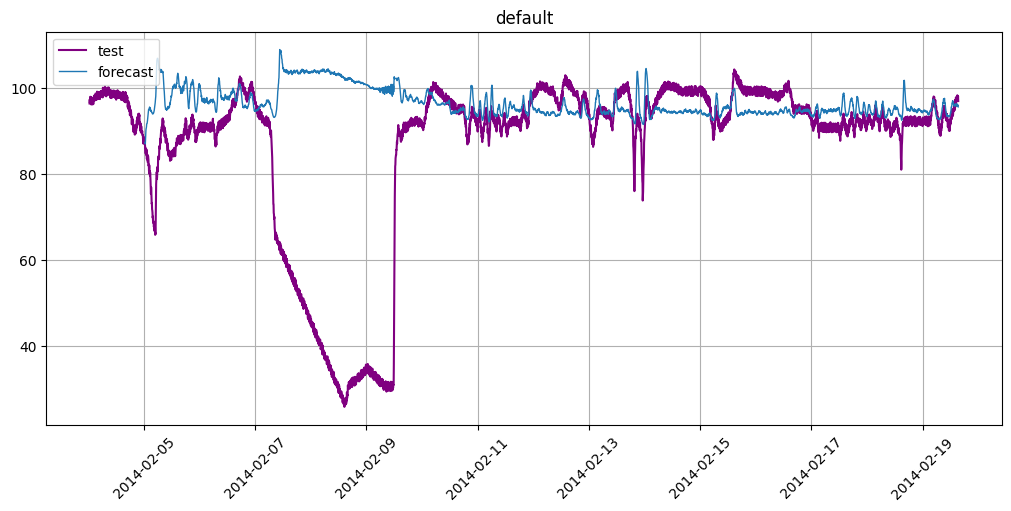

In [ ]:
forecast_deepar = deepar_model.forecast(test_ts, 4212)
plot_forecast(
    forecast_deepar,
    test_ts,
    segments=["default"]
)